In [1]:
import torch
from accelerate import Accelerator
from torch.utils.data import DataLoader
from torchvision import transforms as tf
from torchvision.datasets import FashionMNIST
from torchvision.utils import make_grid, save_image
from torch_ema import ExponentialMovingAverage as EMA
# from tqdm import tqdm
from IPython.display import display
import matplotlib.pyplot as plt
from pathlib import Path
import os 

from smalldiffusion import (
    ScheduleLogLinear, samples, training_loop, MappedDataset, Unet, Scaled,
    img_train_transform, img_normalize
)

from dataset import LatentAudioDataset, decode_audio, load_model as load_audio_codec

from model import LukeUnet


c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
train_batch_size = 16
epochs = 10

EMBEDDINGS_PATH = Path("C:/Users/dzluk/stable-audio-tools/data/blackbird/embeddings")
checkpoint_path = 'checkpoint.pth'

# for now, trim the inputs from [1, 64, 1024] to [1, 64, 64] so they are square
data_transform = tf.Compose([
    tf.Lambda(lambda x: x[:, :, :64]),
])
# data_transform = None

dataset = LatentAudioDataset(EMBEDDINGS_PATH, normalize=False, transform=data_transform)

# Setup
a = Accelerator()
loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)
schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=20, N=800)
model = Scaled(Unet)(in_dim=64, in_ch=1, out_ch=1, ch=128, ch_mult=(1, 1, 2), attn_resolutions=(16,))
# model = Scaled(LukeUnet)(in_dim=(64,128), in_ch=1, out_ch=1, ch=128, ch_mult=(1, 1, 2), attn_resolutions=[(16,16)])

Loss=1.0853:   0%|          | 0/10 [00:00<?, ?it/s]

Loss=0.53077: 100%|██████████| 10/10 [13:56<00:00, 83.68s/it]


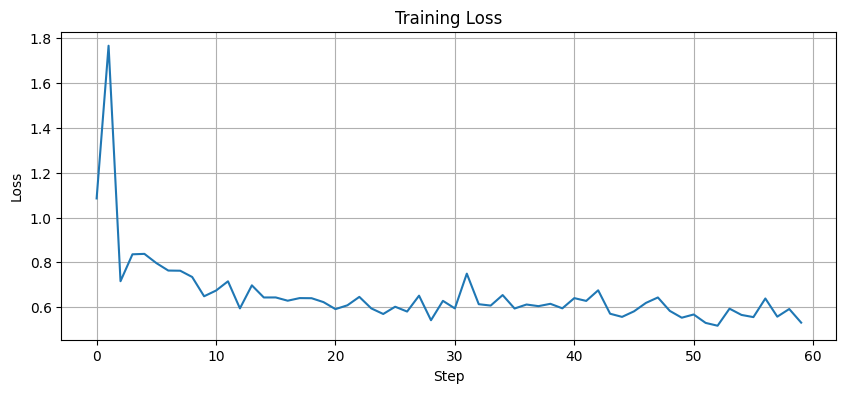

In [35]:
# Train
losses = []
ema = EMA(model.parameters(), decay=0.999)
ema.to(a.device)
for ns in training_loop(loader, model, schedule, epochs=epochs, lr=7e-4, accelerator=a):
    losses.append(ns.loss.item())
    ns.pbar.set_description(f'Loss={ns.loss.item():.5}')
    ema.update()

# Save checkpoint
torch.save(model.state_dict(), checkpoint_path)

# Plot training losses
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [6]:
# Load in SAO Encoder/Decoder to decode the generated latents into audio
codec_model, params = load_audio_codec()

Loading pretrained model stabilityai/stable-audio-open-1.0
No module named 'flash_attn'
flash_attn not installed, disabling Flash Attention


c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 99/99 [00:00<00:00, 1268.03it/s, Materializing param=shared.weight]                                                     


Done loading model
Loaded pretrained model: stabilityai/stable-audio-open-1.0
Device: cuda | Half: False | Sample rate: 44100 | Sample size: 2097152


Loaded model from checkpoint.pth
Sample 1


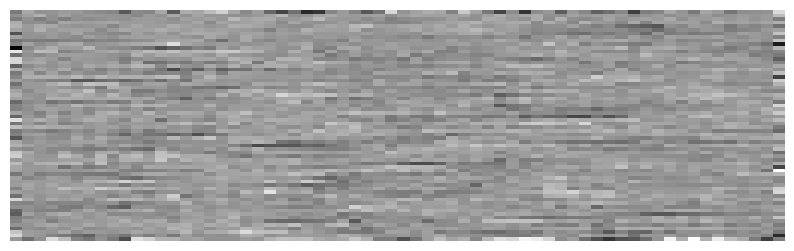

c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


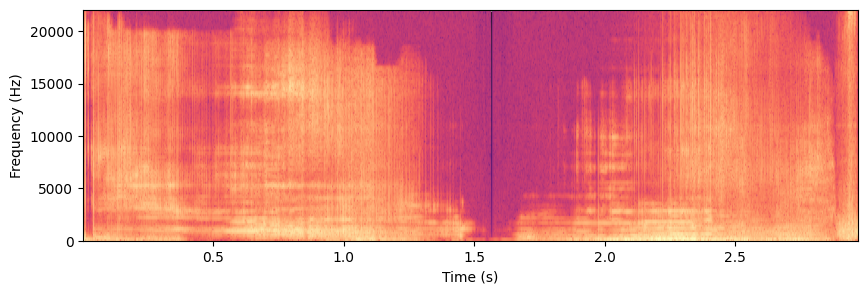


Sample 2


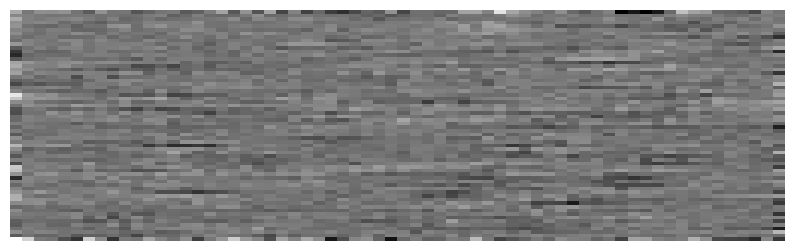

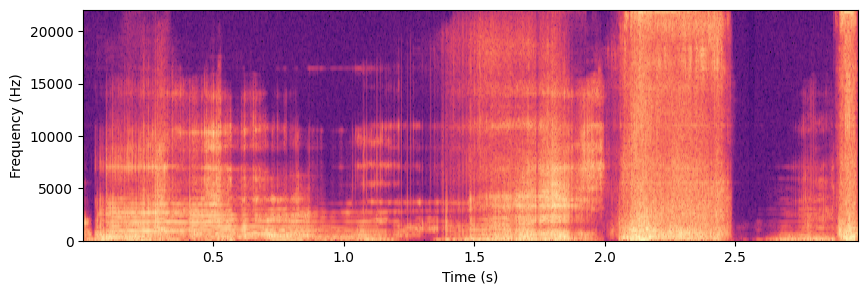

In [ ]:
# Sample
sample_batch_size = 2
load_model = True

# Load pre-trained model (optional - skip to Train cell to train from scratch)

if load_model:
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=a.device))
        print(f"Loaded model from {checkpoint_path}")
    else:
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}, cannot reload model")

with ema.average_parameters():
    *xt, x0 = samples(model, schedule.sample_sigmas(20), gam=1.6,
                        batchsize=sample_batch_size, accelerator=a)

# Decode and display each sample
from IPython.display import Audio, display

for i, x in enumerate(x0):
    # Decode latent to audio
    audio = decode_audio(x, codec_model)
    
    print(f"Sample {i+1}")
    
    # 1. Latent as image
    plt.figure(figsize=(10, 3))
    plt.imshow(x.squeeze().cpu().numpy(), aspect='auto', cmap='gray')
    plt.axis('off')
    plt.show()
    
    # 2. Audio player
    display(Audio(audio, rate=44100))
    
    # 3. Spectrogram
    audio_mono = audio[0] + audio[0] / 2 if audio.ndim > 1 else audio
    plt.figure(figsize=(10, 3))
    plt.specgram(audio_mono, Fs=44100, cmap='magma')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.show()
    print()

In [40]:
model

UnetScaled(
  (sig_embed): SigmaEmbedderSinCos(
    (mlp): Sequential(
      (0): Linear(in_features=2, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (conv_in): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0-1): 2 x Module(
      (blocks): ModuleList(
        (0-1): 2 x CondSequential(
          (0): ResnetBlock(
            (layer1): Sequential(
              (0): GroupNorm(32, 128, eps=1e-06, affine=True)
              (1): SiLU()
              (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
            (temb_proj): Sequential(
              (0): SiLU()
              (1): Linear(in_features=512, out_features=128, bias=True)
            )
            (layer2): Sequential(
              (0): GroupNorm(32, 128, eps=1e-06, affine=True)
              (1): SiLU()
              (2): Dropout(p=0.1, inplace=False)
              (3

In [21]:
x.min()

tensor(-5.0115, device='cuda:0')